Top 20 feature–target correlations:
ret      -0.066842
rsi14     0.039364
volume    0.016260
ema200   -0.015595
sma200   -0.014751
sma50    -0.013359
ema50    -0.012622
close    -0.008896
low      -0.008478
high     -0.007687
open     -0.007182
dtype: float64


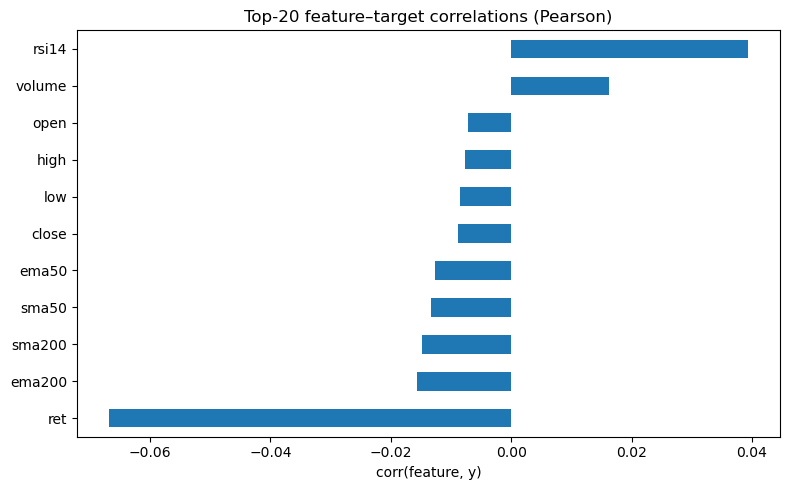

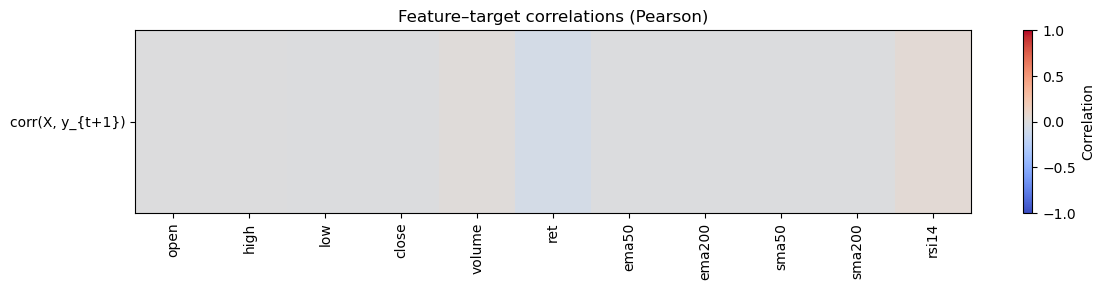

In [13]:
# --- R.2: CORRELATIONS (robust) ---
import os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings("ignore")
os.makedirs("results", exist_ok=True)

# 1) Load final modelling frame (CSV or Parquet)
candidates = [
    Path("results/final_daily_modelling_frame.parquet"),
    Path("results/final_daily_modelling_frame.csv"),
    Path("results/daily_modelling_frame.parquet"),
    Path("results/daily_modelling_frame.csv"),
]
dfm = None
for p in candidates:
    if p.exists():
        dfm = pd.read_parquet(p) if p.suffix == ".parquet" else pd.read_csv(p, parse_dates=["open_time"], index_col="open_time")
        break
if dfm is None:
    raise FileNotFoundError("Final modelling frame not found. Run consolidation first.")

assert "y" in dfm.columns, "Target column 'y' not found."
y = dfm["y"]

# 2) Keep only numeric features, drop 'y'
X = dfm.drop(columns=["y"])
X = X.apply(pd.to_numeric, errors="coerce")
# Drop columns that are entirely NaN (after coercion)
X = X.dropna(axis=1, how="all")

# Align indexes (just in case)
idx = X.index.intersection(y.index)
X = X.loc[idx]
y = y.loc[idx]

# 3) Compute feature–target Pearson correlations
corr_series = X.corrwith(y)
# Rank by absolute value (top 20)
top20 = corr_series.sort_values(key=np.abs, ascending=False).head(20)
print("Top 20 feature–target correlations:")
print(top20)

# Save the full correlation table for the thesis (sorted by |corr|)
corr_table = corr_series.sort_values(key=np.abs, ascending=False).to_frame("corr_with_y")
corr_table.to_csv("results/R2_feature_target_correlations.csv")
spearman = X.corrwith(y, method="spearman").sort_values(key=np.abs, ascending=False)
spearman.to_csv("results/R2_feature_target_correlations_spearman.csv")

# 4) Bar plot of top-20
plt.figure(figsize=(8, 5))
top20.sort_values().plot(kind="barh")
plt.title("Top-20 feature–target correlations (Pearson)")
plt.xlabel("corr(feature, y)")
plt.tight_layout()
plt.savefig("results/fig_R2_top20_corr.png")
plt.show()

# 5) Heat 'row' (fix: use NumPy, not Series[None, :])
# Order by X.columns so ticks line up
vals = corr_series.reindex(X.columns).fillna(0).values
mat = np.atleast_2d(vals)  # shape (1, n_features)

plt.figure(figsize=(12, 3))
im = plt.imshow(mat, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
plt.yticks([0], ["corr(X, y_{t+1})"])

# Tidy xticks (thin if too many)
n = len(X.columns)
step = max(1, n // 50)  # show up to ~50 labels
positions = np.arange(0, n, step)
labels = [X.columns[i] for i in positions]
plt.xticks(positions, labels, rotation=90)
plt.colorbar(im, label="Correlation")
plt.title("Feature–target correlations (Pearson)")
plt.tight_layout()
plt.savefig("results/fig_R2_corr_matrix.png")
plt.show()


Top-15 (by |Pearson|):
              pearson  spearman
ret_lag1     0.057615  0.041221
rsi14_lag1   0.048004  0.033336
ret_lag3     0.045528  0.011993
rsi14_lag2   0.039493  0.025709
rsi14_lag3   0.037979  0.020209
rsi14_lag4   0.033037  0.025710
ret_lag7    -0.030797 -0.021375
rsi14_lag5   0.023128  0.016506
ema200_lag7 -0.018197 -0.026651
ema200_lag6 -0.018136 -0.026629
ema200_lag5 -0.018079 -0.026673
ema200_lag4 -0.018017 -0.026698
ema200_lag3 -0.017938 -0.026763
ema200_lag2 -0.017857 -0.026825
ema200_lag1 -0.017763 -0.026958

Top-15 (by Mutual Information):
volume_lag6    0.045209
ema200_lag5    0.036814
ema200_lag6    0.035413
rsi14_lag5     0.035083
ema200_lag7    0.033985
ema200_lag1    0.029439
ema200_lag4    0.028617
low_lag7       0.027155
ema200_lag2    0.025259
ema200_lag3    0.023032
volume_lag7    0.022161
ema50_lag1     0.020680
volume_lag5    0.019522
open_lag6      0.018247
close_lag7     0.017675
Name: mutual_info, dtype: float64


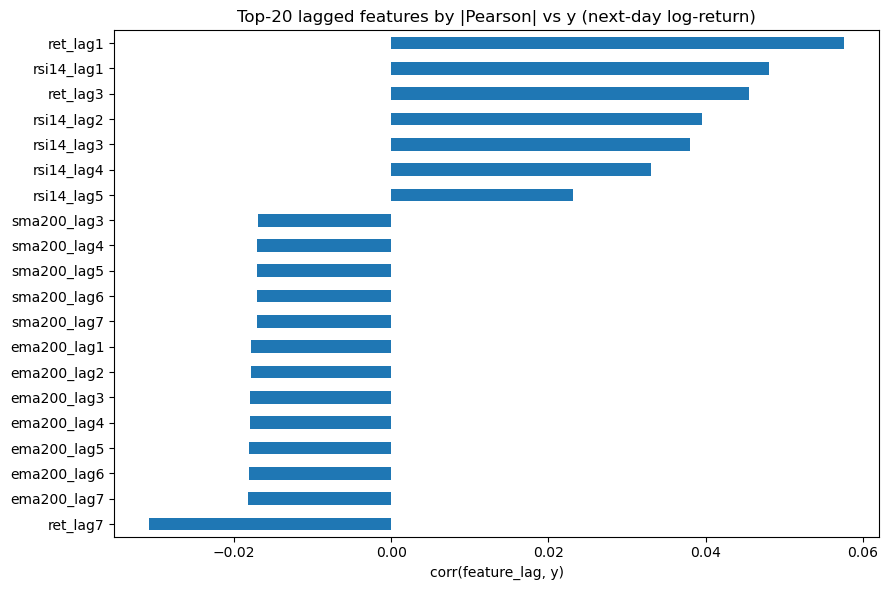

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\vasil\\AppData\\Roaming\\jupyterlab-desktop\\jlab_server\\condabin\\results\\fig_R2_lag_heatmap_Momentum\\Volume.png'

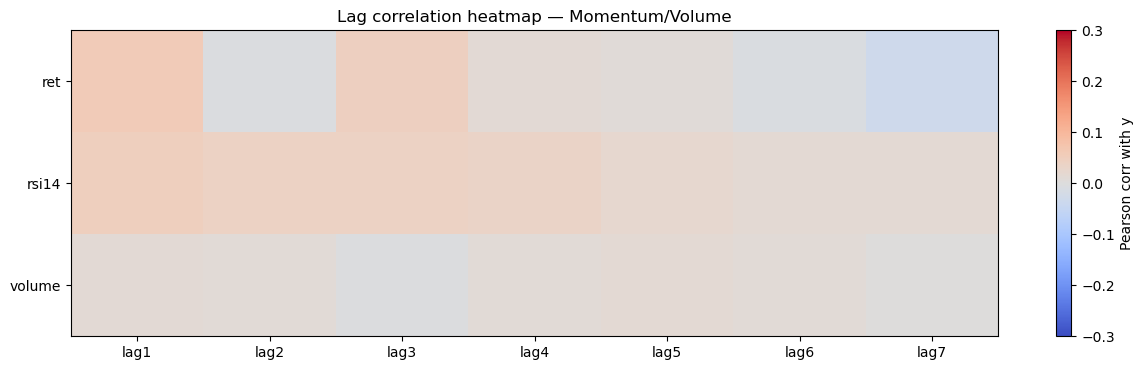

In [14]:
# --- R.2+: Correlations with LAGS + Spearman + Mutual Information ---
import os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.feature_selection import mutual_info_regression

warnings.filterwarnings("ignore")
os.makedirs("results", exist_ok=True)

# 1) Load modelling frame
candidates = [
    Path("results/final_daily_modelling_frame.parquet"),
    Path("results/final_daily_modelling_frame.csv"),
    Path("results/daily_modelling_frame.parquet"),
    Path("results/daily_modelling_frame.csv"),
]
dfm = None
for p in candidates:
    if p.exists():
        dfm = pd.read_parquet(p) if p.suffix == ".parquet" else pd.read_csv(p, parse_dates=["open_time"], index_col="open_time")
        break
if dfm is None:
    raise FileNotFoundError("Final modelling frame not found. Run consolidation first.")

assert "y" in dfm.columns, "Target 'y' missing."

# 2) Choose base features (use what you have)
base_feats = [c for c in ["ret","rsi14","ema50","ema200","sma50","sma200","volume",
                          "hash_rate","difficulty","sent_compound","sent_pos","sent_neg","sent_neu","close","open","high","low"]
              if c in dfm.columns]

# 3) Build 1..7 day lags for each base feature (avoid leakage)
MAX_LAG = 7
lag_cols = []
lag_df = pd.DataFrame(index=dfm.index)
for f in base_feats:
    for k in range(1, MAX_LAG+1):
        col = f"{f}_lag{k}"
        lag_df[col] = dfm[f].shift(k)
        lag_cols.append(col)

# 4) Assemble X (lagged only) and y; drop NaNs
X = lag_df
y = dfm["y"]
idx = X.index.intersection(y.index)
X = X.loc[idx].apply(pd.to_numeric, errors="coerce")
y = y.loc[idx]
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask]
y = y.loc[mask]

# 5) Pearson & Spearman correlations
pearson = X.corrwith(y).rename("pearson")
spearman = X.corrwith(y, method="spearman").rename("spearman")
corr_all = pd.concat([pearson, spearman], axis=1).sort_values("pearson", key=np.abs, ascending=False)
corr_all.to_csv("results/R2_lagged_correlations_pearson_spearman.csv")

# 6) Mutual Information (captures non-linear dependence)
mi = mutual_info_regression(X.values, y.values, random_state=42)
mi_s = pd.Series(mi, index=X.columns, name="mutual_info").sort_values(ascending=False)
mi_s.to_csv("results/R2_lagged_mutual_information.csv")

print("Top-15 (by |Pearson|):")
print(corr_all.head(15))
print("\nTop-15 (by Mutual Information):")
print(mi_s.head(15))

# 7) Plots
# 7.1 Top-20 Pearson bar
top20 = corr_all.reindex(pearson.abs().sort_values(ascending=False).head(20).index)
plt.figure(figsize=(9,6))
top20["pearson"].sort_values().plot(kind="barh")
plt.title("Top-20 lagged features by |Pearson| vs y (next-day log-return)")
plt.xlabel("corr(feature_lag, y)")
plt.tight_layout(); plt.savefig("results/fig_R2_top20_lagged_pearson.png"); plt.show()

# 7.2 Lag heatmaps for a few key families
def plot_lag_heat(feature_names, title_stub):
    present = [f for f in feature_names if f in base_feats]
    if not present:
        return
    # Build matrix: rows=features, cols=lag1..lagK
    mat = []
    row_labels = []
    for f in present:
        vals = []
        for k in range(1, MAX_LAG+1):
            col = f"{f}_lag{k}"
            vals.append(pearson.get(col, np.nan))
        mat.append(vals)
        row_labels.append(f)
    mat = np.array(mat)
    plt.figure(figsize=(1.5*MAX_LAG+2, 0.6*len(present)+2))
    im = plt.imshow(mat, aspect="auto", cmap="coolwarm", vmin=-0.3, vmax=0.3)
    plt.colorbar(im, label="Pearson corr with y")
    plt.yticks(range(len(present)), row_labels)
    plt.xticks(range(MAX_LAG), [f"lag{k}" for k in range(1, MAX_LAG+1)], rotation=0)
    plt.title(f"Lag correlation heatmap — {title_stub}")
    plt.tight_layout(); plt.savefig(f"results/fig_R2_lag_heatmap_{title_stub.replace(' ','_')}.png"); plt.show()

plot_lag_heat(["ret","rsi14","volume"], "Momentum/Volume")
plot_lag_heat(["ema50","ema200","sma50","sma200"], "Trend MAs")
plot_lag_heat(["hash_rate","difficulty"], "Network")
plot_lag_heat(["sent_compound","sent_pos","sent_neg","sent_neu"], "Sentiment")

# 7.3 Rolling correlation of the best 3 lagged predictors (180D window)
best3 = pearson.abs().sort_values(ascending=False).head(3).index.tolist()
if best3:
    roll_win = 180
    plt.figure(figsize=(10,4))
    for col in best3:
        s = pd.concat([X[col], y], axis=1).dropna()
        rc = s[col].rolling(roll_win).corr(s["y"])
        rc.plot(label=col)
    plt.title(f"Rolling Pearson corr (window={roll_win}d) of top lagged features vs y")
    plt.xlabel("Date"); plt.ylabel("Rolling corr")
    plt.legend(); plt.tight_layout(); plt.savefig("results/fig_R2_rolling_corr_top3.png"); plt.show()
